<a href="https://colab.research.google.com/github/naguibahmed961-art/My-Projects/blob/main/rainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

In [ ]:
import pickle

In [ ]:
df=pd.read_csv('/content/usa_rain_prediction_dataset_2024_2025.csv')
df.head(15)

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0
5,2024-01-06,New York,35.298648,56.598099,21.442424,0.582661,22.825103,1036.043397,0
6,2024-01-07,New York,50.380818,95.424193,8.753319,0.000000,36.820958,1032.337889,0
7,2024-01-08,New York,79.967007,28.186104,27.495322,0.105845,77.807459,1039.897652,0
8,2024-01-09,New York,36.565489,72.099621,19.885635,0.910368,34.333699,975.446601,1
9,2024-01-10,New York,69.600506,30.248213,0.325415,0.000000,46.825566,1039.132281,0


In [ ]:
df.shape

(73100, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           73100 non-null  object 
 1   Location       73100 non-null  object 
 2   Temperature    73100 non-null  float64
 3   Humidity       73100 non-null  float64
 4   Wind Speed     73100 non-null  float64
 5   Precipitation  73100 non-null  float64
 6   Cloud Cover    73100 non-null  float64
 7   Pressure       73100 non-null  float64
 8   Rain Tomorrow  73100 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 5.0+ MB


Data Filtering

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation,0
Cloud Cover,0
Pressure,0
Rain Tomorrow,0


In [ ]:
df.duplicated().sum()
# "df.drop_duplicates(inplace=True)"

np.int64(0)

In [ ]:
# 2. Feature Engineering (Bring back Date & Location)
# Extract Month from Date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

In [ ]:
# Encode Location
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])

In [ ]:
df.head()

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow,Month
0,2024-01-01,11,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0,1
1,2024-01-02,11,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0,1
2,2024-01-03,11,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1,1
3,2024-01-04,11,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0,1
4,2024-01-05,11,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0,1


In [ ]:
# 3. Drop Leakage and Unused Columns
df = df.drop(['Date', 'Precipitation'], axis=1)
df.head()

,Location,Temperature,Humidity,Wind Speed,Cloud Cover,Pressure,Rain Tomorrow,Month
0,11,87.524795,75.655455,28.379506,69.617966,1026.030278,0,1
1,11,83.259325,28.712617,12.436433,41.606048,995.962065,0,1
2,11,80.943050,64.740043,14.184831,77.364763,980.796739,1,1
3,11,78.097552,59.738984,19.444029,52.541196,979.012163,0,1
4,11,37.059963,34.766784,3.689661,85.584000,1031.790859,0,1


In [ ]:
df = df.rename(columns={
    'Rain Tomorrow': 'Rain_Tomorrow',
    'Wind Speed': 'Wind_Speed',
    'Cloud Cover': 'Cloud_Cover'
})
df.head()

,Location,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain_Tomorrow,Month
0,11,87.524795,75.655455,28.379506,69.617966,1026.030278,0,1
1,11,83.259325,28.712617,12.436433,41.606048,995.962065,0,1
2,11,80.943050,64.740043,14.184831,77.364763,980.796739,1,1
3,11,78.097552,59.738984,19.444029,52.541196,979.012163,0,1
4,11,37.059963,34.766784,3.689661,85.584000,1031.790859,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       73100 non-null  int64  
 1   Temperature    73100 non-null  float64
 2   Humidity       73100 non-null  float64
 3   Wind_Speed     73100 non-null  float64
 4   Cloud_Cover    73100 non-null  float64
 5   Pressure       73100 non-null  float64
 6   Rain_Tomorrow  73100 non-null  int64  
 7   Month          73100 non-null  int32  
dtypes: float64(5), int32(1), int64(2)
memory usage: 4.2 MB


In [ ]:
df.describe()

,Location,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain_Tomorrow,Month
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,9.500000,65.182270,59.875041,15.017946,54.942807,1005.176013,0.220410,6.519836
std,5.766321,20.205793,23.066115,8.668729,25.982487,20.203889,0.414526,3.449574
min,0.000000,30.000766,20.000272,0.000712,10.000856,970.000919,0.000000,1.000000
25%,4.750000,47.678968,39.800732,7.485182,32.318668,987.697646,0.000000,4.000000
50%,9.500000,65.294949,59.887840,15.102495,55.011121,1005.284188,0.000000,7.000000
75%,14.250000,82.636570,79.835990,22.551794,77.412469,1022.727410,0.000000,10.000000
max,19.000000,99.997393,99.999025,29.999017,99.998957,1039.999765,1.000000,12.000000


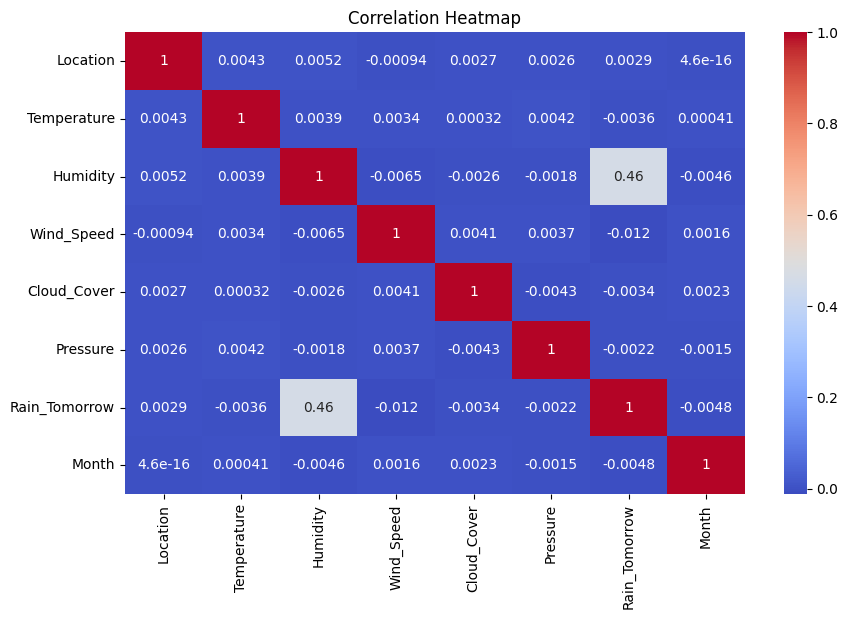

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<Axes: xlabel='Rain_Tomorrow', ylabel='count'>

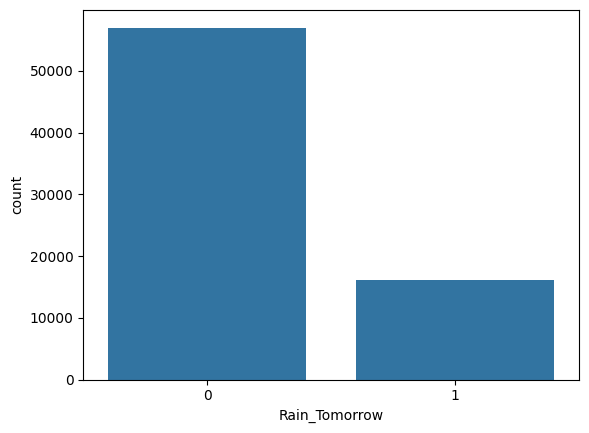

In [ ]:
sns.countplot(x='Rain_Tomorrow', data=df)

In [ ]:
df.Rain_Tomorrow.value_counts()

,count
Rain_Tomorrow,
0,56988
1,16112


In [ ]:
#Data not palanced
will_rain = df.Rain_Tomorrow.value_counts()[1]
will_not_rain = df.Rain_Tomorrow.value_counts()[0]
will_rain

np.int64(16112)

In [ ]:
df['Rain_Tomorrow'].unique()

array([0, 1])

In [ ]:
df['Rain_Tomorrow'].value_counts(normalize=True)

,proportion
Rain_Tomorrow,
0,0.77959
1,0.22041


In [ ]:
df.Rain_Tomorrow.value_counts()

,count
Rain_Tomorrow,
0,56988
1,16112


In [ ]:
# Features and target
x = df.drop('Rain_Tomorrow', axis=1)
y = df['Rain_Tomorrow']

In [ ]:
x.shape

(73100, 7)

In [ ]:
y.shape

(73100,)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#6. Scaling (Optional for Random Forest, but good practice)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limit tree depth
    min_samples_split=5,  # Minimum samples to split a node
    min_samples_leaf=2,  # Minimum samples in leaf nodes
    random_state=42
)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

In [ ]:
print("New Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

New Accuracy: 0.7797537619699042

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     11398
           1       0.51      0.01      0.03      3222

    accuracy                           0.78     14620
   macro avg       0.65      0.50      0.45     14620
weighted avg       0.72      0.78      0.69     14620



In [ ]:
y_pred = clf.predict(X_test)
from sklearn import metrics
print("mse ",metrics.mean_squared_error(y_test, y_pred))
print("rmse ",np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("mae ",metrics.mean_absolute_error(y_test, y_pred))
print("r2 ",metrics.r2_score(y_test, y_pred))


mse  0.23850889192886457
rmse  0.4883737215789406
mae  0.23850889192886457
r2  -0.3881779165848409


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


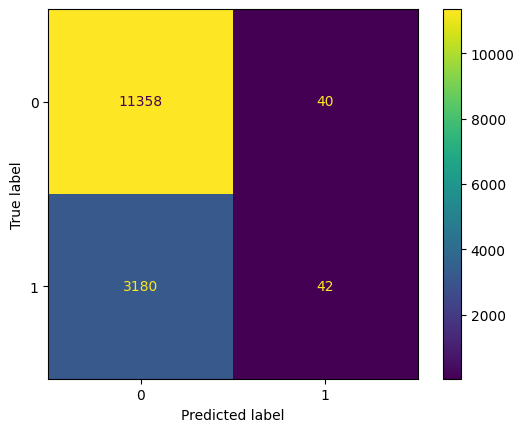

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp = disp.plot()

plt.show()

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

# Define the prediction function
def predict_rainfall(location_code, temperature, humidity, wind_speed, cloud_cover, pressure, month):
    # 1. Prepare the input array matching the columns:
    # [Location, Temperature, Humidity, Wind Speed, Cloud Cover, Pressure, Month]
    input_data = np.array([[location_code, temperature, humidity, wind_speed, cloud_cover, pressure, month]])

    # 2. Scale the input using the scaler you trained earlier
    # Note: We use a dataframe to keep column names consistent if the scaler expects them
    feature_names = ['Location', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure', 'Month']
    input_df = pd.DataFrame(input_data, columns=feature_names)

    scaled_input = scaler.transform(input_df)

    # 3. Make prediction
    prediction = clf.predict(scaled_input)
    probability = clf.predict_proba(scaled_input)[0][1] # Probability of rain

    # 4. Return result
    if prediction[0] == 1:
        return f"🌧️ YES, it will rain tomorrow! (Confidence: {probability:.2%})"
    else:
        return f"☀️ NO, it will not rain tomorrow. (Chance of rain: {probability:.2%})"

# Create the Gradio Interface
interface = gr.Interface(
    fn=predict_rainfall,
    inputs=[
        gr.Number(label="Location Code (0-19)", value=11), # Assuming Location is label encoded 0-19
        gr.Slider(minimum=-10, maximum=120, label="Temperature (°F)", value=65),
        gr.Slider(minimum=0, maximum=100, label="Humidity (%)", value=60),
        gr.Number(label="Wind Speed (mph)", value=15),
        gr.Slider(minimum=0, maximum=100, label="Cloud Cover (%)", value=50),
        gr.Number(label="Pressure (hPa)", value=1013),
        gr.Slider(minimum=1, maximum=12, step=1, label="Month (1-12)", value=6)
    ],
    outputs="text",
    title="☔ AI Rainfall Predictor",
    description="Enter weather data to predict if it will rain tomorrow using your Random Forest model."
)

# Launch the app
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0c36baea96c6bfc600.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import numpy as np
import pandas as pd

# Define the custom threshold for predicting "Rain"
CUSTOM_THRESHOLD = 0.40 # Start with 0.40 (40%) and adjust if needed

# Define the prediction function
def predict_rainfall(location_code, temperature, humidity, wind_speed, cloud_cover, pressure, month):
    # Ensure clf and scaler objects are available in your Colab session

    # 1. Prepare the input array matching the columns in the correct order
    input_data = np.array([[location_code, temperature, humidity, wind_speed, cloud_cover, pressure, month]])

    # Define feature names for scaling/consistency
    feature_names = ['Location', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure', 'Month']
    input_df = pd.DataFrame(input_data, columns=feature_names)

    # 2. Scale the input
    scaled_input = scaler.transform(input_df)

    # 3. Get the probability of rain (class 1)
    probability = clf.predict_proba(scaled_input)[0][1]

    # 4. Apply the custom threshold
    if probability >= CUSTOM_THRESHOLD:
        return f"🌧️ YES, it will rain tomorrow! (Confidence: {probability:.2%})"
    else:
        return f"☀️ NO, it will not rain tomorrow. (Chance of rain: {probability:.2%})"

# Re-run the interface with the updated function
interface = gr.Interface(
    fn=predict_rainfall,
    inputs=[
        gr.Number(label="Location Code (0-19)", value=15),
        gr.Slider(minimum=-10, maximum=120, label="Temperature (°F)", value=55),
        gr.Slider(minimum=0, maximum=100, label="Humidity (%)", value=90),
        gr.Number(label="Wind Speed (mph)", value=20),
        gr.Slider(minimum=0, maximum=100, label="Cloud Cover (%)", value=95),
        gr.Number(label="Pressure (hPa)", value=995),
        gr.Slider(minimum=1, maximum=12, step=1, label="Month (1-12)", value=11)
    ],
    outputs="text",
    title="☔ AI Rainfall Predictor (Threshold: 40%)",
    description="Enter weather data to predict if it will rain tomorrow."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6f5ececf3f4320796f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
